# CVM Simulation - Case

### Critical Warning

**Asking any AI tool (GPT, Claude, Gemini or others) to run or solve this case autonomously without answering each question step by step is detectable and will result in poor answers and being disqualified from the process. What do we expect? The candidate shall use AI collaboratively to expand your knowledge and capabilities and augment your analytics capabilities.**

Author: Juan David Rodriguez

CellMov is a converged operator in Latin America. CellMov is the country's market leader in mobile but a distant number two in fixed broadband. Conjoint analysis and consulting projects have identified that pairing mobile service with the right fixed product represents a significant cross-sell opportunity.

Detailed call analysis on selected samples has also shown that conversion is significantly impacted by the first offer presented to a customer. If the initial pitch is not appealing, customers normally hang up the phone.

Carla Henriquez, the new CMO of the company, wants to truly exploit this opportunity. The current process of offer assignment is not very analytical. Offers are mostly assigned depending on monthly promotion strategies, without much personalization. In some months they are offered quasi-randomly.

After many failed experiments, and considering that propensity to convert was proven to be elastic (dependent on price), operations managers have decided to focus on offering a single offer: Low Speed Internet and Basic TV.

She has hired you to analyze data and build an AI-based recommender to ensure customers receive the right offer while optimizing for total margin.

#### **The portfolio**

CellMov can offer the following products to its customers:
- **Internet:** It can be either a low-speed offer (150 Mbps) or a very high-speed offer (1,000 Mbps). Internet is a mandatory feature in any proposed offer.
- **TV:** It can be either a basic package including only local channels or a premium package with international channels that include sports, news, movies, and other entertainment. TV is optional — customers may receive no TV offer.
- **OTT bundles:** Disney and Paramount services can be offered as bundles. In addition to a bundle discount, the payment process is simpler for customers when included in the internet service, especially for users who do not have access to a credit card.
- **Voice:** Although fixed voice services are losing relevance, some users require it as part of their fixed product.
- **Guaranteed wall-to-wall WiFi:** CellMov has a premium product that offers an in-home WiFi design, up to two beacon extenders, and an application that allows control of connected devices, network topology, frequency optimization, and other advanced features.

Pricing and margins for each offer component are detailed in the table below:

| Product | Price | COGS | CPE / Installation Depreciation | Commission Amortization | Margin | % Margin |
|:---|---:|---:|---:|---:|---:|---:|
| Internet — High Speed | $40.00 | $2.00 | $4.17 | $2.22 | $31.61 | 79% |
| Internet — Low Speed | $25.00 | $2.00 | $2.78 | $1.39 | $18.83 | 75% |
| TV — Basic | $10.00 | $3.00 | $1.94 | $0.56 | $4.50 | 45% |
| TV — Premium | $23.00 | $8.00 | $1.94 | $1.28 | $11.78 | 51% |
| Disney Bundle | $10.00 | $5.00 | $— | $— | $5.00 | 50% |
| Paramount Bundle | $8.00 | $4.00 | $— | $— | $4.00 | 50% |
| VoIP Line | $8.00 | $2.00 | $— | $0.44 | $5.56 | 69% |
| Wall-to-Wall WiFi | $4.00 | $0.50 | $1.25 | $— | $2.25 | 56% |

### **User Features**

The analytics team has already developed a pipeline to generate leads with the following information:

- **Phone number:** The mobile phone number of the customer that the campaign will target for cross-selling.
- **Age:** Current age of the customer.
- **Socio-Economic Segment:** Segment of the customer, where A is very affluent and D is the lowest income level.
- **Mobility Profile:** There are four mobility profiles: 1) Users who are almost exclusively at home. 2) Users who commute between home and work. 3) Customers who frequent a home, a workplace, and a regular third location after work. 4) Users with very high mobility across multiple locations.
- **Device:** Customer device type.
- **Total data usage (GB)**
- **YouTube data usage (GB)**
- **WhatsApp data usage (GB)**
- **Netflix data usage (GB)**
- **Disney data usage (GB)**
- **Other OTT data usage (GB)**
- **News webpages data usage (GB)**
- **Sports webpages data usage (GB)**

### **Initial Experiments**

As the new CVM director, you decide to run two experiments to understand conversion and how the base responds to two different strategies:
- **Random Offer:** You ask your analytics team to assign a random offer including features to a 100k user base.
- **Same low-cost offer:** Given the demand elasticity mentioned by operations management, you run a second test offering Low Speed Internet plus Basic TV (no optional add-ons included).

In [1]:
#### Do not modify this cell, check how functions are called
from data_and_supporting_code.base import generate_lead_base

In [2]:
lead_base = generate_lead_base(n=100_000)
lead_base.head()

,phone_number,age,socio_economic_segment,mobility_profile,device,total_usage_gb,youtube_gb,whatsapp_gb,netflix_gb,disney_gb,other_ott_gb,news_portals_gb,sports_portals_gb
0,69171301,23,A,Home - Mostly in one cell,iPhone mid end,12.50,4.961,1.372,1.184,1.051,0.040,0.162,1.110
1,65977306,37,D,Home - Work profile,iPhone mid end,18.95,2.604,2.072,2.984,3.009,2.997,0.046,1.221
2,66325754,43,D,High mobility - Multiple Sites,Android low end,3.88,1.158,0.503,0.598,0.397,0.096,0.001,0.062
3,67123461,37,A,Home - Mostly in one cell,iPhone high end,9.26,0.897,1.517,0.769,0.322,0.340,0.088,0.577
4,62457609,22,C,Home - Work - Third Site Profile,Android high end,13.19,3.224,0.337,0.936,0.808,1.139,0.216,4.513


**Coding cell: follow the instructions**

Use Python or SQLite to run descriptive analytics on the distribution of your base variables.

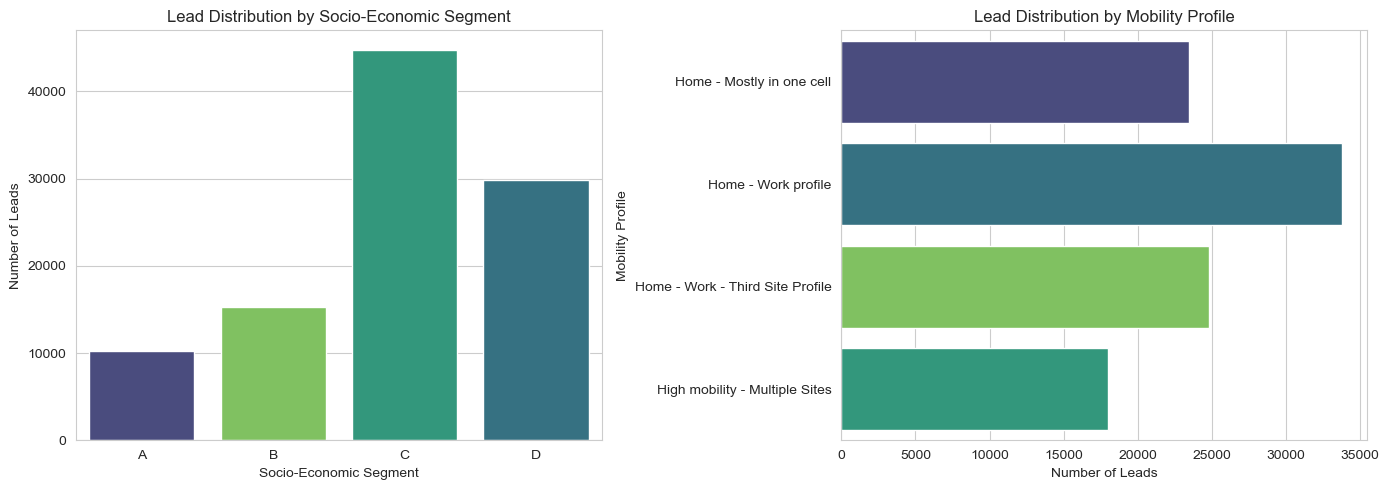

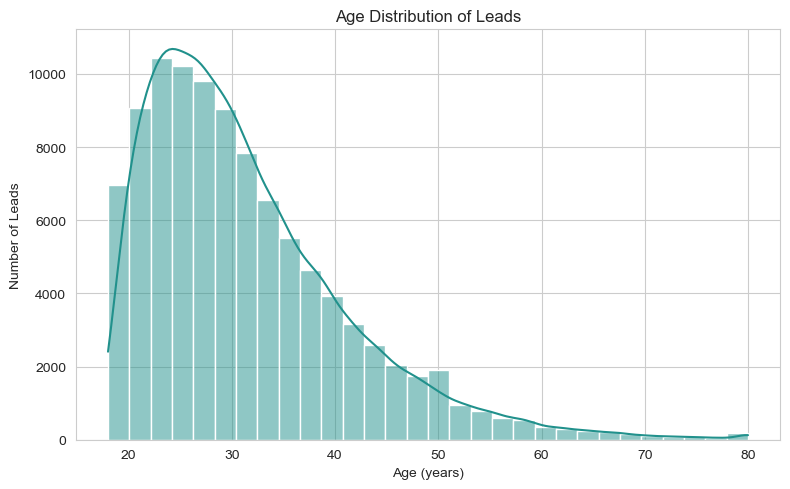

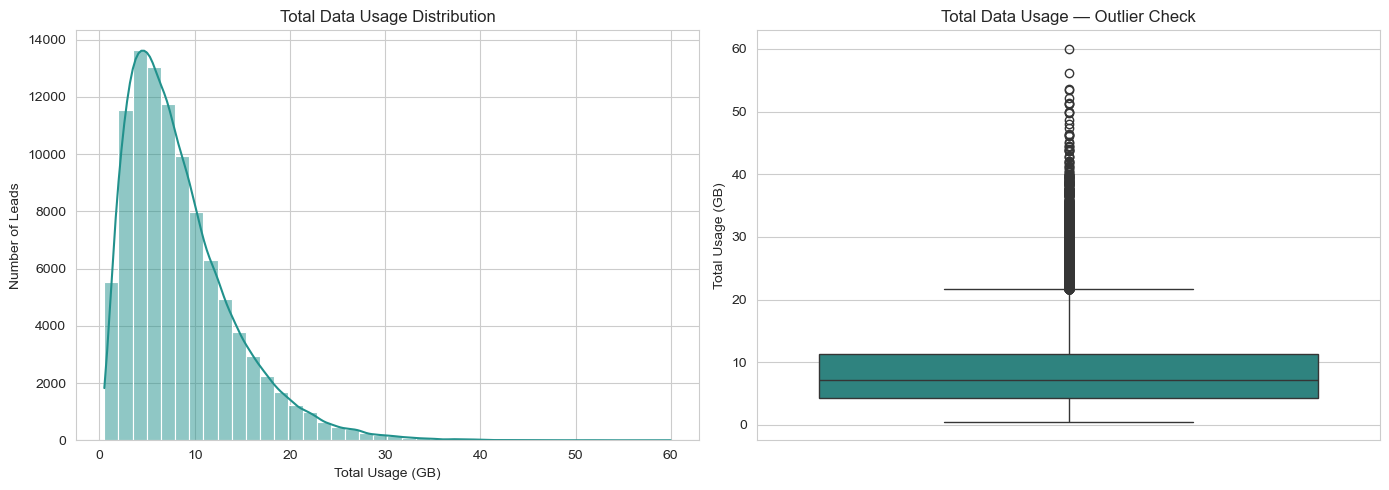

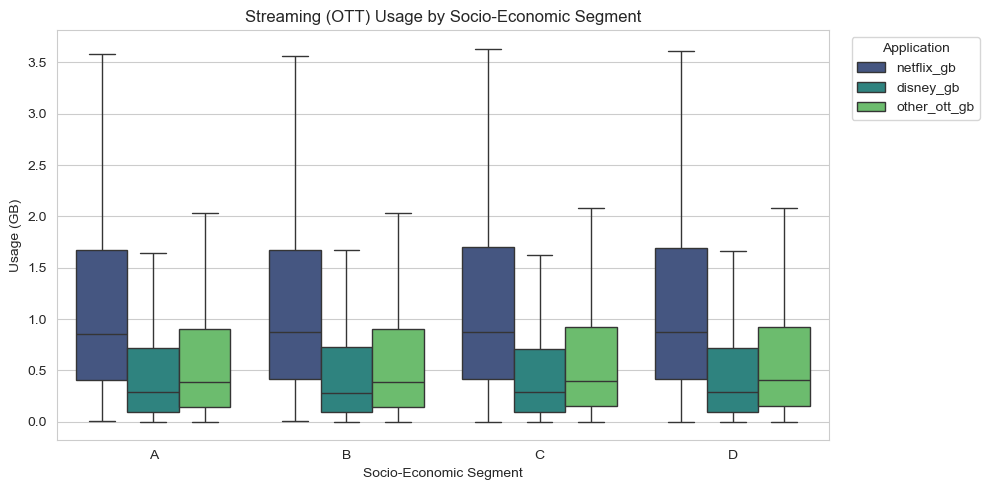

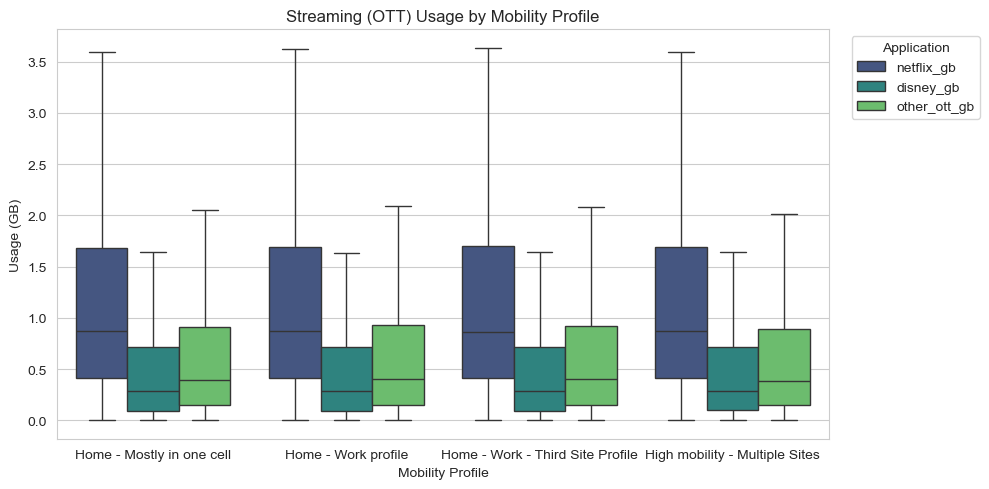

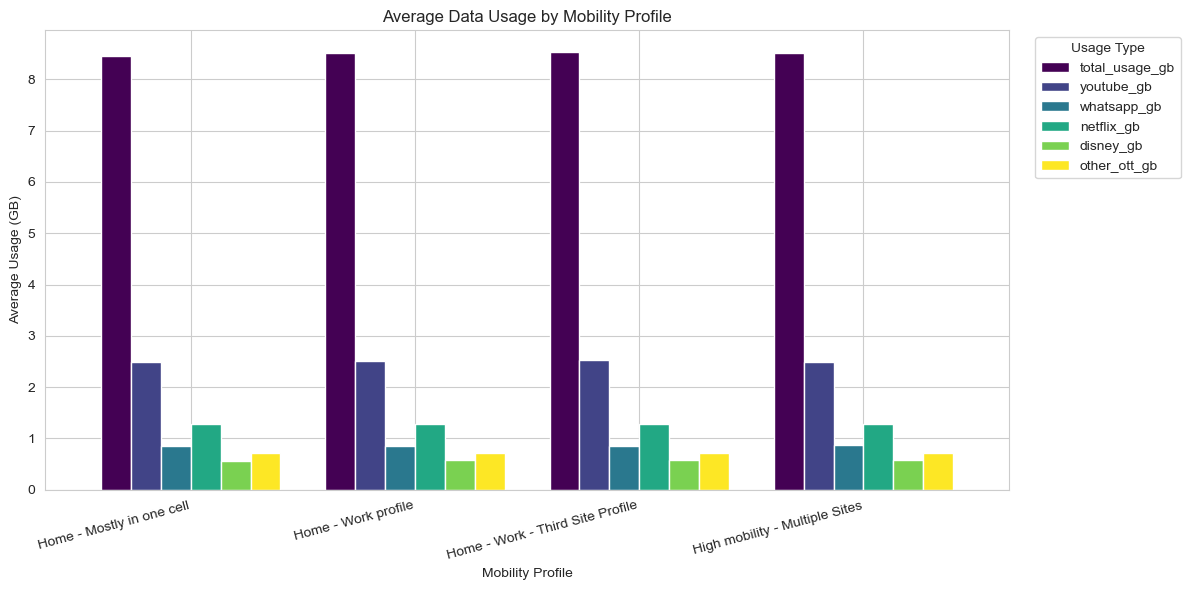

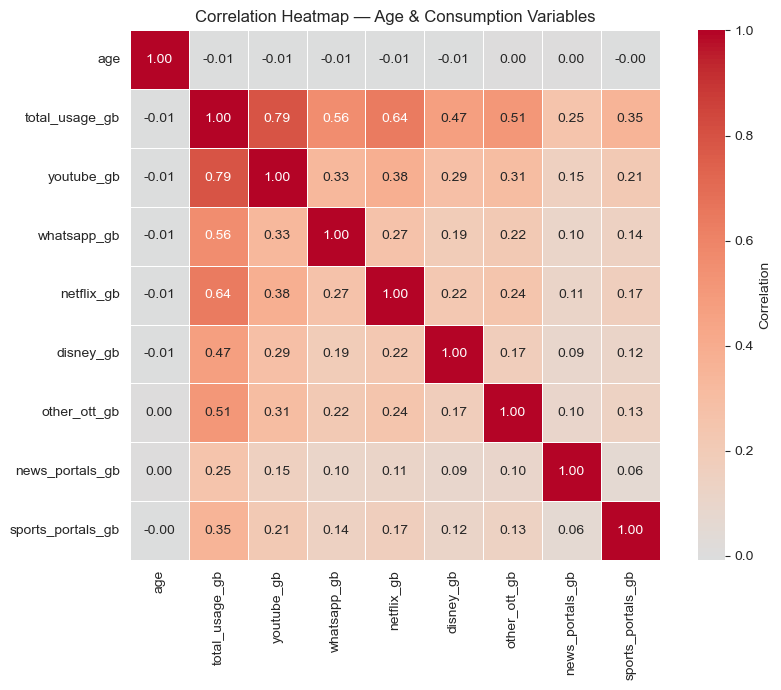

In [3]:
# ============================================================
# Descriptive Analytics: Lead Base Profiling
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
PALETTE = "viridis"
plt.rcParams["figure.dpi"] = 100

# Explicit, business-meaningful ordering for categorical variables
segment_order = ["A", "B", "C", "D"]
mobility_order = [
    "Home - Mostly in one cell",
    "Home - Work profile",
    "Home - Work - Third Site Profile",
    "High mobility - Multiple Sites",
]

app_usage_cols = ["youtube_gb", "whatsapp_gb", "netflix_gb", "disney_gb", "other_ott_gb"]
ott_cols = ["netflix_gb", "disney_gb", "other_ott_gb"]
numeric_consumption_cols = ["age", "total_usage_gb"] + app_usage_cols + ["news_portals_gb", "sports_portals_gb"]

# ------------------------------------------------------------
# Section 1: Univariate Analysis — Who is our customer base?
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(
    data=lead_base, x="socio_economic_segment", order=segment_order,
    hue="socio_economic_segment", palette=PALETTE, legend=False, ax=axes[0],
)
axes[0].set_title("Lead Distribution by Socio-Economic Segment")
axes[0].set_xlabel("Socio-Economic Segment")
axes[0].set_ylabel("Number of Leads")

sns.countplot(
    data=lead_base, y="mobility_profile", order=mobility_order,
    hue="mobility_profile", palette=PALETTE, legend=False, ax=axes[1],
)
axes[1].set_title("Lead Distribution by Mobility Profile")
axes[1].set_xlabel("Number of Leads")
axes[1].set_ylabel("Mobility Profile")

plt.tight_layout()
plt.show()

# Age distribution
plt.figure(figsize=(8, 5))
sns.histplot(data=lead_base, x="age", bins=30, kde=True, color=sns.color_palette(PALETTE, 1)[0])
plt.title("Age Distribution of Leads")
plt.xlabel("Age (years)")
plt.ylabel("Number of Leads")
plt.tight_layout()
plt.show()

# Total data usage: histogram + boxplot side by side (distribution shape + outliers)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=lead_base, x="total_usage_gb", bins=40, kde=True, ax=axes[0], color=sns.color_palette(PALETTE, 1)[0])
axes[0].set_title("Total Data Usage Distribution")
axes[0].set_xlabel("Total Usage (GB)")
axes[0].set_ylabel("Number of Leads")

sns.boxplot(data=lead_base, y="total_usage_gb", ax=axes[1], color=sns.color_palette(PALETTE, 3)[1])
axes[1].set_title("Total Data Usage — Outlier Check")
axes[1].set_ylabel("Total Usage (GB)")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Section 2: Multivariate Analysis — Business-driven insights
# ------------------------------------------------------------

def boxplot_by_category(data, category_col, order, value_cols, title, xlabel):
    """Plot side-by-side boxplots of `value_cols` grouped by a categorical column."""
    melted = data.melt(
        id_vars=category_col, value_vars=value_cols,
        var_name="app", value_name="usage_gb",
    )
    plt.figure(figsize=(10, 5))
    sns.boxplot(
        data=melted, x=category_col, y="usage_gb", hue="app",
        order=order, palette=PALETTE, showfliers=False,
    )
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Usage (GB)")
    plt.legend(title="Application", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


# Streaming (OTT) usage vs. Socio-Economic Segment
# Why: identify which segments are more likely to buy OTT bundles / Premium TV.
boxplot_by_category(
    lead_base, "socio_economic_segment", segment_order, ott_cols,
    "Streaming (OTT) Usage by Socio-Economic Segment",
    "Socio-Economic Segment",
)

# Streaming (OTT) usage vs. Mobility Profile
# Why: home-based profiles may be better OTT/Premium-TV targets than high-mobility ones.
boxplot_by_category(
    lead_base, "mobility_profile", mobility_order, ott_cols,
    "Streaming (OTT) Usage by Mobility Profile",
    "Mobility Profile",
)

# Mobility profile vs. total and app-level usage (mean comparison)
# Why: test whether high-mobility profiles (3 & 4) skew toward mobile data usage
# while home-based profiles (1 & 2) skew toward streaming — informs whether to target
# Wall-to-Wall WiFi (home-based) vs. high mobile data plans (high-mobility).
mobility_summary = (
    lead_base.groupby("mobility_profile")[["total_usage_gb"] + app_usage_cols]
    .mean()
    .reindex(mobility_order)
)

mobility_summary.plot(kind="bar", figsize=(12, 6), colormap=PALETTE, width=0.8)
plt.title("Average Data Usage by Mobility Profile")
plt.xlabel("Mobility Profile")
plt.ylabel("Average Usage (GB)")
plt.xticks(rotation=15, ha="right")
plt.legend(title="Usage Type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Correlation heatmap of numerical consumption variables
# Why: discover which applications are consumed together (e.g., YouTube & WhatsApp)
# to design custom bundles.
plt.figure(figsize=(9, 7))
corr = lead_base[numeric_consumption_cols].corr()
sns.heatmap(
    corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
    square=True, linewidths=0.5, cbar_kws={"label": "Correlation"},
)
plt.title("Correlation Heatmap — Age & Consumption Variables")
plt.tight_layout()
plt.show()



### **Simulation**

**Coding cell: follow the instructions**

Use Python to split the `lead_base` dataframe into `random_base` and `low_offer_base`. **Use the exact naming convention.** Assign the first 50,000 records to the random base and the second 50,000 records to the second base.

In [4]:
# First 50,000 records (from 0 to 49,999)
random_base = lead_base.iloc[:50_000].reset_index(drop=True)

# Second 50,000 records (from 50,000 to 99,999) using the exact naming convention
low_offer_base = lead_base.iloc[50_000:100_000].reset_index(drop=True)

print(f"random_base size:    {random_base.shape}")
display(random_base.head())
print(f"low_offer_base size: {low_offer_base.shape}")
display(low_offer_base.head())

# Assign low_offer_base to low_cost_base to ensure compatibility with subsequent code cells
low_cost_base = low_offer_base

random_base size:    (50000, 13)


,phone_number,age,socio_economic_segment,mobility_profile,device,total_usage_gb,youtube_gb,whatsapp_gb,netflix_gb,disney_gb,other_ott_gb,news_portals_gb,sports_portals_gb
0,69171301,23,A,Home - Mostly in one cell,iPhone mid end,12.50,4.961,1.372,1.184,1.051,0.040,0.162,1.110
1,65977306,37,D,Home - Work profile,iPhone mid end,18.95,2.604,2.072,2.984,3.009,2.997,0.046,1.221
2,66325754,43,D,High mobility - Multiple Sites,Android low end,3.88,1.158,0.503,0.598,0.397,0.096,0.001,0.062
3,67123461,37,A,Home - Mostly in one cell,iPhone high end,9.26,0.897,1.517,0.769,0.322,0.340,0.088,0.577
4,62457609,22,C,Home - Work - Third Site Profile,Android high end,13.19,3.224,0.337,0.936,0.808,1.139,0.216,4.513


low_offer_base size: (50000, 13)


,phone_number,age,socio_economic_segment,mobility_profile,device,total_usage_gb,youtube_gb,whatsapp_gb,netflix_gb,disney_gb,other_ott_gb,news_portals_gb,sports_portals_gb
0,67724480,30,C,Home - Work profile,iPhone mid end,1.66,0.474,0.194,0.053,0.008,0.218,0.011,0.496
1,61359810,28,C,Home - Mostly in one cell,Android high end,14.05,3.903,1.463,0.172,3.202,1.000,0.085,0.350
2,63620003,29,D,High mobility - Multiple Sites,Android low end,4.81,3.489,0.172,0.661,0.028,0.291,0.004,0.001
3,62595458,24,D,Home - Work - Third Site Profile,iPhone high end,10.95,4.468,1.084,1.532,0.053,1.157,0.322,0.436
4,68174650,28,A,Home - Mostly in one cell,Android high end,5.64,2.714,1.371,0.720,0.150,0.201,0.159,0.168


Assign offers using functions from the experiment library.

In [5]:
### Do not modify this cell

from data_and_supporting_code.experiments import random_offer as random_offer_fn, fixed_offer

random_offer = random_offer_fn(random_base)
low_cost_offer = fixed_offer(low_cost_base)

print(f"random_offer size:    {random_offer.shape}")
display(random_offer.head())
print(f"low_cost_offer size: {low_cost_offer.shape}")
display(low_cost_offer.head())

random_offer size:    (50000, 22)


,phone_number,age,socio_economic_segment,mobility_profile,device,total_usage_gb,youtube_gb,whatsapp_gb,netflix_gb,disney_gb,...,sports_portals_gb,offer_high_speed_internet,offer_low_speed_internet,offer_basic_tv,offer_premium_tv,offer_disney_ott,offer_paramount_ott,offer_voice_line,offer_wall_to_wall_wifi,offer_description
0,69171301,23,A,Home - Mostly in one cell,iPhone mid end,12.50,4.961,1.372,1.184,1.051,...,1.110,1,0,0,1,1,0,0,0,High Speed Internet + Premium TV + Disney OTT
1,65977306,37,D,Home - Work profile,iPhone mid end,18.95,2.604,2.072,2.984,3.009,...,1.221,1,0,0,0,0,0,0,0,High Speed Internet
2,66325754,43,D,High mobility - Multiple Sites,Android low end,3.88,1.158,0.503,0.598,0.397,...,0.062,0,1,1,0,0,1,1,0,Low Speed Internet + Basic TV + Paramount OTT ...
3,67123461,37,A,Home - Mostly in one cell,iPhone high end,9.26,0.897,1.517,0.769,0.322,...,0.577,1,0,1,0,1,0,1,0,High Speed Internet + Basic TV + Disney OTT + ...
4,62457609,22,C,Home - Work - Third Site Profile,Android high end,13.19,3.224,0.337,0.936,0.808,...,4.513,0,1,0,0,1,1,0,1,Low Speed Internet + Disney OTT + Paramount OT...


low_cost_offer size: (50000, 22)


,phone_number,age,socio_economic_segment,mobility_profile,device,total_usage_gb,youtube_gb,whatsapp_gb,netflix_gb,disney_gb,...,sports_portals_gb,offer_high_speed_internet,offer_low_speed_internet,offer_basic_tv,offer_premium_tv,offer_disney_ott,offer_paramount_ott,offer_voice_line,offer_wall_to_wall_wifi,offer_description
0,67724480,30,C,Home - Work profile,iPhone mid end,1.66,0.474,0.194,0.053,0.008,...,0.496,0,1,1,0,0,0,0,0,Low Speed Internet + Basic TV
1,61359810,28,C,Home - Mostly in one cell,Android high end,14.05,3.903,1.463,0.172,3.202,...,0.350,0,1,1,0,0,0,0,0,Low Speed Internet + Basic TV
2,63620003,29,D,High mobility - Multiple Sites,Android low end,4.81,3.489,0.172,0.661,0.028,...,0.001,0,1,1,0,0,0,0,0,Low Speed Internet + Basic TV
3,62595458,24,D,Home - Work - Third Site Profile,iPhone high end,10.95,4.468,1.084,1.532,0.053,...,0.436,0,1,1,0,0,0,0,0,Low Speed Internet + Basic TV
4,68174650,28,A,Home - Mostly in one cell,Android high end,5.64,2.714,1.371,0.720,0.150,...,0.168,0,1,1,0,0,0,0,0,Low Speed Internet + Basic TV


In [6]:
from data_and_supporting_code.sim import sim

random_results = sim(random_offer)
low_cost_results = sim(low_cost_offer)

display(random_results.head())

print(f"Random offer converted:        {random_results['converted'].sum():,} ({random_results['converted'].sum() / len(random_results):.1%})")
print(f"Random Margin:                 {random_results['total_margin'].sum():,.2f}")
print()
print(f"Low cost offer converted:         {low_cost_results['converted'].sum():,} ({low_cost_results['converted'].sum() / len(low_cost_results):.1%})")
print(f"Los cost offer Margin:                  {low_cost_results['total_margin'].sum():,.2f}")

,phone_number,offer_high_speed_internet,offer_low_speed_internet,offer_basic_tv,offer_premium_tv,offer_disney_ott,offer_paramount_ott,offer_voice_line,offer_wall_to_wall_wifi,offer_description,offer_description,total_price,total_margin,converted
0,69171301,1,0,0,1,1,0,0,0,High Speed Internet + Premium TV + Disney OTT,High Speed Internet + Premium TV + Disney OTT,73,0.0,False
1,65977306,1,0,0,0,0,0,0,0,High Speed Internet,High Speed Internet,40,0.0,False
2,66325754,0,1,1,0,0,1,1,0,Low Speed Internet + Basic TV + Paramount OTT ...,Low Speed Internet + Basic TV + Paramount OTT ...,53,0.0,False
3,67123461,1,0,1,0,1,0,1,0,High Speed Internet + Basic TV + Disney OTT + ...,High Speed Internet + Basic TV + Disney OTT + ...,68,0.0,False
4,62457609,0,1,0,0,1,1,0,1,Low Speed Internet + Disney OTT + Paramount OT...,Low Speed Internet + Disney OTT + Paramount OT...,49,0.0,False


Random offer converted:        346 (0.7%)
Random Margin:                 13,476.99

Low cost offer converted:         1,531 (3.1%)
Los cost offer Margin:                  38,366.86


**Coding cell: follow the instructions**

Use Python or SQLite to run descriptive analytics on your results. Using the random offer converted results, try to model price elasticity. Provide relevant insights from both experiments to understand customer preferences.

=== Overall Conversion Rate Comparison ===
       Experiment  Conversion Rate  Avg. Total Margin ($)
0    Random Offer           0.0069                 0.2695
1  Low-Cost Offer           0.0306                 0.7673

=== Top Bundles by Conversion Rate: Random Offer ===
                                                    customers  \
offer_description                                               
High Speed Internet + Wall to Wall Wifi                   533   
High Speed Internet + Premium TV + Disney OTT +...        501   
Low Speed Internet                                        550   
High Speed Internet + Premium TV + Wall to Wall...        504   
High Speed Internet + Premium TV + Paramount OT...        521   
High Speed Internet + Premium TV + Disney OTT +...        532   
High Speed Internet + Disney OTT + Wall to Wall...        535   
High Speed Internet                                       498   
High Speed Internet + Disney OTT + Paramount OT...        505   
Low Speed Inte

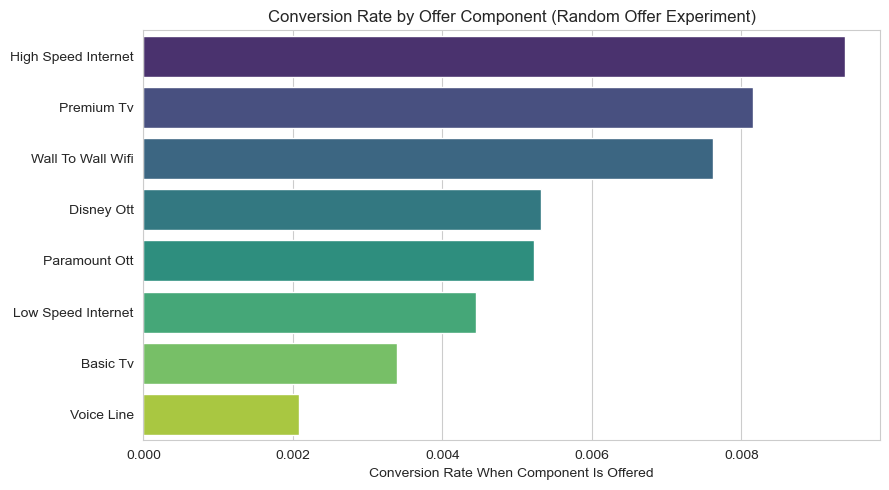


=== Price Elasticity Model: Logit(converted) ~ total_price + product mix ===
                           Logit Regression Results                           
Dep. Variable:              converted   No. Observations:                50000
Model:                          Logit   Df Residuals:                    49992
Method:                           MLE   Df Model:                            7
Date:                Fri, 17 Jul 2026   Pseudo R-squ.:                 0.07983
Time:                        14:09:12   Log-Likelihood:                -1900.7
converged:                       True   LL-Null:                       -2065.6
Covariance Type:            nonrobust   LLR p-value:                 2.610e-67
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                        -5.6941      0.805     -7.071      0.000      -7.272      -4.116
total_pr

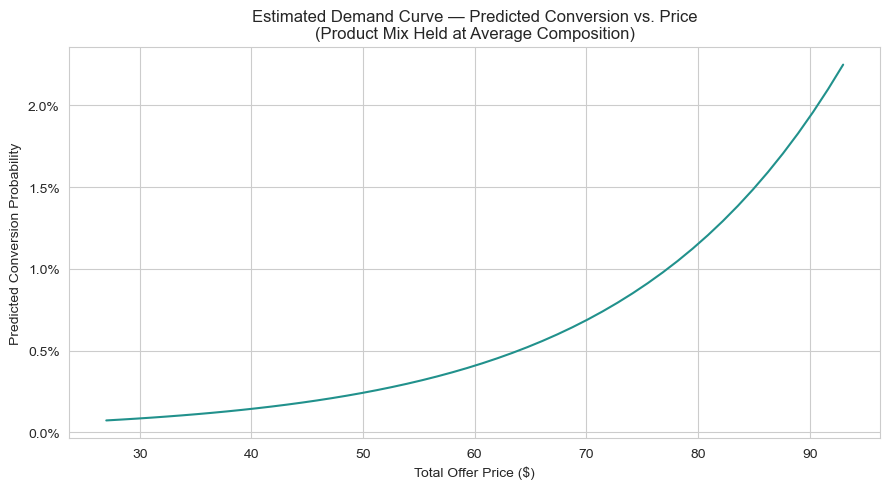


=== Interpreting the Price Coefficient ===
- Coefficient sign: positive (0.0523 log-odds per $1) — higher price increases the odds of conversion, holding product mix fixed, consistent with standard demand theory.
- Odds ratio 1.0537: each extra $1 charged multiplies the odds of conversion by 1.0537 (-5.37% relative change in odds per dollar).

=== Conversion Shift: Random Baseline -> Low-Cost Strategy ===
- Random offer:   avg. price $59.52 -> conversion rate 0.69%
- Low-cost offer: avg. price $37.00 -> conversion rate 3.06%
- Lowering price by $22.52 on average shifted conversion by 2.37 percentage points (4.42x baseline), directionally consistent with the negative price coefficient estimated above — though the low-cost offer also strips out add-ons (Premium TV, OTT bundles, Voice, WiFi), so part of this shift reflects a simpler, less confusing product mix in addition to the pure price effect.


In [ ]:
import statsmodels.api as sm
import pandas as pd
import numpy as np
import matplotlib.ticker as mtick

sns.set_style("whitegrid")
PALETTE = "viridis"

random_results = random_results.loc[:, ~random_results.columns.duplicated()]
low_cost_results = low_cost_results.loc[:, ~low_cost_results.columns.duplicated()]


# ============================================================
# Section 1: Comparative Descriptive Analytics
# ============================================================

offer_feature_cols = [
    "offer_high_speed_internet", "offer_low_speed_internet", "offer_basic_tv",
    "offer_premium_tv", "offer_disney_ott", "offer_paramount_ott",
    "offer_voice_line", "offer_wall_to_wall_wifi",
]

# 1a. Overall conversion rate: random (varied offers) vs. low-cost (fixed offer)
conversion_comparison = pd.DataFrame({
    "Experiment": ["Random Offer", "Low-Cost Offer"],
    "Conversion Rate": [random_results["converted"].mean(), low_cost_results["converted"].mean()],
    "Avg. Total Margin ($)": [random_results["total_margin"].mean(), low_cost_results["total_margin"].mean()],
})
print("=== Overall Conversion Rate Comparison ===")
print(conversion_comparison.round(4))


def bundle_performance(results_df, top_n=10):
    """Conversion rate and average margin per unique offer bundle."""
    return (
        results_df.groupby("offer_description")
        .agg(
            customers=("converted", "size"),
            conversion_rate=("converted", "mean"),
            avg_margin_per_customer=("total_margin", "mean"),
        )
        .sort_values("conversion_rate", ascending=False)
        .head(top_n)
    )

print("\n=== Top Bundles by Conversion Rate: Random Offer ===")
print(bundle_performance(random_results).round(4))

print("\n=== Top Bundles by Conversion Rate: Low-Cost Offer ===")

print(bundle_performance(low_cost_results).round(4))

# 1c. Individual component conversion rate: acceptance rate when a feature IS offered
# (meaningful only in the random experiment, since the low-cost experiment never
# varies these components)
component_conversion = pd.DataFrame({
    "Offer Component": [c.replace("offer_", "").replace("_", " ").title() for c in offer_feature_cols],
    "Conversion Rate When Offered": [
        random_results.loc[random_results[c] == 1, "converted"].mean() for c in offer_feature_cols
    ],
}).sort_values("Conversion Rate When Offered", ascending=False)
print("\n=== Conversion Rate by Individual Offer Component (Random Offer) ===")
print(component_conversion.round(4))

plt.figure(figsize=(9, 5))
sns.barplot(
    data=component_conversion, x="Conversion Rate When Offered", y="Offer Component",
    hue="Offer Component", palette=PALETTE, legend=False,
)
plt.title("Conversion Rate by Offer Component (Random Offer Experiment)")
plt.xlabel("Conversion Rate When Component Is Offered")
plt.ylabel("")
plt.tight_layout()
plt.show()

# ============================================================
# Section 2: Price Elasticity Modeling (Random Offer Experiment)
# ============================================================


model_flags = [
    "offer_high_speed_internet", "offer_basic_tv", "offer_premium_tv",
    "offer_disney_ott", "offer_paramount_ott", "offer_voice_line",
]

X = sm.add_constant(random_results[["total_price"] + model_flags])
y = random_results["converted"].astype(int)

assert np.linalg.matrix_rank(X.values) == X.shape[1], "Design matrix is rank-deficient"

price_mix_model = sm.Logit(y, X).fit(disp=False)
print("\n=== Price Elasticity Model: Logit(converted) ~ total_price + product mix ===")
print(price_mix_model.summary())

price_coef = price_mix_model.params["total_price"]
print(f"\nHolding product mix fixed, each additional $1 in price changes the "
      f"log-odds of conversion by {price_coef:.4f} (odds ratio: {np.exp(price_coef):.4f}).")
if price_mix_model.pvalues["total_price"] > 0.05:
    print("Note: this effect is not statistically significant at the 5% level in "
          "this run — expected, since once product mix is held fixed, the only "
          "remaining price variation comes from the $4 Wall-to-Wall WiFi add-on, "
          "a narrow range that limits the power to detect a pure price effect.")

# 2b. Estimated demand curve: predicted conversion probability across price tiers,
# holding the product mix fixed at its average observed composition
price_grid = np.linspace(random_results["total_price"].min(), random_results["total_price"].max(), 50)
avg_mix = random_results[model_flags].mean()

X_grid = pd.DataFrame({"total_price": price_grid})
for flag in model_flags:
    X_grid[flag] = avg_mix[flag]
X_grid.insert(0, "const", 1.0)
X_grid = X_grid[X.columns]  # match fitted model's column order exactly

predicted_curve = pd.DataFrame({
    "total_price": price_grid,
    "predicted_conversion_rate": price_mix_model.predict(X_grid),  # kept as raw 0-1 probability
})

plt.figure(figsize=(9, 5))
sns.lineplot(
    data=predicted_curve, x="total_price", y="predicted_conversion_rate",
    color=sns.color_palette(PALETTE, 1)[0],
)
plt.title("Estimated Demand Curve — Predicted Conversion vs. Price\n(Product Mix Held at Average Composition)")
plt.xlabel("Total Offer Price ($)")
plt.ylabel("Predicted Conversion Probability")

plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=1))
plt.tight_layout()
plt.show()

# ============================================================
# Section 3: Experiment Insights — Random Baseline vs. Low-Cost Strategy
# ============================================================

random_conv = random_results["converted"].mean()
low_cost_conv = low_cost_results["converted"].mean()
random_price = random_results["total_price"].mean()
low_cost_price = low_cost_results["total_price"].mean()

print("\n=== Interpreting the Price Coefficient ===")
print(f"- Coefficient sign: {'negative' if price_coef < 0 else 'positive'} "
      f"({price_coef:.4f} log-odds per $1) — higher price "
      f"{'reduces' if price_coef < 0 else 'increases'} the odds of conversion, "
      "holding product mix fixed, consistent with standard demand theory.")
print(f"- Odds ratio {np.exp(price_coef):.4f}: each extra $1 charged multiplies the odds "
      f"of conversion by {np.exp(price_coef):.4f} "
      f"({(1 - np.exp(price_coef)) * 100:.2f}% relative change in odds per dollar).")

print("\n=== Conversion Shift: Random Baseline -> Low-Cost Strategy ===")
print(f"- Random offer:   avg. price ${random_price:.2f} -> conversion rate {random_conv:.2%}")
print(f"- Low-cost offer: avg. price ${low_cost_price:.2f} -> conversion rate {low_cost_conv:.2%}")
print(f"- Lowering price by ${random_price - low_cost_price:.2f} on average shifted conversion by "
      f"{(low_cost_conv - random_conv) * 100:.2f} percentage points "
      f"({low_cost_conv / random_conv:.2f}x baseline), directionally consistent with the negative "
      "price coefficient estimated above — though the low-cost offer also strips out add-ons "
      "(Premium TV, OTT bundles, Voice, WiFi), so part of this shift reflects a simpler, "
      "less confusing product mix in addition to the pure price effect.")





## Building your recommender model

In [8]:
### Do not modify this cell

for i in range(1, 11):
    globals()[f"train_leads_optimized_{i}"] = generate_lead_base(n=50_000)

#This loop created ten train datasets (train_leads_optimized_1, train_leads_optimized_2,train_leads_optimized_3... train_leads_optimized_10)
display(train_leads_optimized_1.head())

test_leads_optimized = generate_lead_base(n=50_000)

,phone_number,age,socio_economic_segment,mobility_profile,device,total_usage_gb,youtube_gb,whatsapp_gb,netflix_gb,disney_gb,other_ott_gb,news_portals_gb,sports_portals_gb
0,62979420,21,A,Home - Work profile,iPhone high end,8.69,1.818,0.652,3.395,0.064,0.030,0.008,0.001
1,66104828,44,D,High mobility - Multiple Sites,Android high end,3.98,0.912,0.076,1.767,0.002,0.667,0.002,0.000
2,66427646,21,D,Home - Work - Third Site Profile,Android low end,10.65,4.226,1.105,0.576,1.501,0.411,0.051,0.025
3,67351670,31,A,Home - Mostly in one cell,Android high end,1.42,0.278,0.123,0.180,0.087,0.144,0.000,0.054
4,69886313,29,C,Home - Work profile,Android high end,3.93,2.252,0.239,0.226,0.037,0.061,0.000,0.137


You will now build a recommender model that optimizes the offer presented to each customer. Use the `leads_optimized` base from the cell above to test your offer strategy. 

### Important constraint:

You can only use the 500.000 leads created for the 10 batches of leads for training `train_leads_optimized_1` to `train_leads_optimized_10`. This resembles 10 biweekly campaign runs. Your solution shall be tested then with the `test_leads_optimized` to compare results against the random assignment and the low_cost assignment.

### How to run the sim function:

Offer results can be obtained with the `sim` function as follows:

*optimized_results = sim(optimized_offer)*

Your `optimized_offer` dataframe must include the following columns to run the simulation:

- **Columns from the original base** (no transformation needed — **please do not make any changes to the originally created columns**): `phone_number`, `age`, `socio_economic_segment`, `mobility_profile`, `device`, `total_usage_gb`, `youtube_gb`, `whatsapp_gb`, `netflix_gb`, `disney_gb`, `other_ott_gb`, `news_portals_gb`, `sports_portals_gb`
- **Offer columns** — one-hot encoding for each offer feature (1 or 0): `offer_high_speed_internet`, `offer_low_speed_internet`, `offer_basic_tv`, `offer_premium_tv`, `offer_disney_ott`, `offer_paramount_ott`, `offer_voice_line`, `offer_wall_to_wall_wifi`

**Important: If your dataframe does not include any of these columns, the `sim` function will fail. It will also fail if a customer does not have an Internet offer assigned or if both TV options are simultaneously offered**

The `sim` function will run the campaign and return results that can be compared with the random and low-cost strategies.

### Critical Warning

This case has been tested with several AI solutions. AI support is permitted (and encouraged), but the candidate must fully understand, explain, and be able to modify any code provided.

The function `sim()` must be treated as a **black-box stochastic environment**. Its internal logic is unknown and must not be reverse-engineered or inferred.

Any solution will be **disqualified** if it relies on:

* Reverse engineering or deterministic assignment based on `sim()`
* Exhaustive or near-exhaustive evaluation of all offer combinations
  (real campaigns are costly and slow, so brute-force approaches are not feasible)

Candidates should build a **learning-based recommendation policy** (e.g., reinforcement learning, contextual bandits, or similar) that:

* Learns from **limited interactions** with `sim()`
* Balances **exploration and exploitation**
* Generalizes to unseen customers (not a lookup table)

Submissions will be evaluated on methodology, sample efficiency, generalization, and clarity.





In [9]:
# ============================================================
# Contextual Bandit — Offer Personalization Policy
# ============================================================

import itertools
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

sns.set_style("whitegrid")
PALETTE = "viridis"

In [10]:
# ============================================================
# SECTION 1: Feature Engineering
# ============================================================

CATEGORICAL_COLS = ["socio_economic_segment", "mobility_profile", "device"]
NUMERIC_COLS = [
    "age", "total_usage_gb", "youtube_gb", "whatsapp_gb", "netflix_gb",
    "disney_gb", "other_ott_gb", "news_portals_gb", "sports_portals_gb",
]
OFFER_FLAG_COLS = [
    "offer_high_speed_internet", "offer_low_speed_internet", "offer_basic_tv",
    "offer_premium_tv", "offer_disney_ott", "offer_paramount_ott",
    "offer_voice_line", "offer_wall_to_wall_wifi",
]

# One shared preprocessing pipeline for context + action features:
#   - categorical customer attributes -> one-hot (simple, fully interpretable)
#   - numeric usage attributes        -> standardized (mean 0, unit variance)
#   - offer flags                     -> passthrough (already 0/1)

preprocessor = ColumnTransformer(transformers=[
    ("categorical", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_COLS),
    ("numeric", StandardScaler(), NUMERIC_COLS),
    ("offer_flags", "passthrough", OFFER_FLAG_COLS),
])

In [11]:
# ============================================================
# SECTION 2: Action Space & Constraint Mapping
# ============================================================

PRODUCT_MARGINS = {
    "offer_high_speed_internet": 31.61, "offer_low_speed_internet": 18.83,
    "offer_basic_tv": 4.50, "offer_premium_tv": 11.78,
    "offer_disney_ott": 5.00, "offer_paramount_ott": 4.00,
    "offer_voice_line": 5.56, "offer_wall_to_wall_wifi": 2.25,
}
PRODUCT_PRICES = {
    "offer_high_speed_internet": 40, "offer_low_speed_internet": 25,
    "offer_basic_tv": 10, "offer_premium_tv": 23,
    "offer_disney_ott": 10, "offer_paramount_ott": 8,
    "offer_voice_line": 8, "offer_wall_to_wall_wifi": 4,
}


def build_action_space() -> pd.DataFrame:
    """
    Enumerate every VALID offer combination:
      - Internet is mandatory and exclusive: exactly one of
        {high_speed, low_speed} is 1 (2 options).
      - TV is optional and mutually exclusive: none / basic / premium
        (3 options — never both).
      - Disney, Paramount, Voice, Wall-to-Wall WiFi are independent add-ons
        (2^4 = 16 combinations).
    Total valid actions: 2 * 3 * 16 = 96. Invalid combinations (no internet,
    or both TV options) are never constructed, so hard constraints are
    satisfied by design rather than filtered after the fact.
    """
    internet_options = [
        {"offer_high_speed_internet": 1, "offer_low_speed_internet": 0},
        {"offer_high_speed_internet": 0, "offer_low_speed_internet": 1},
    ]
    tv_options = [
        {"offer_basic_tv": 0, "offer_premium_tv": 0},
        {"offer_basic_tv": 1, "offer_premium_tv": 0},
        {"offer_basic_tv": 0, "offer_premium_tv": 1},
    ]
    addon_flags = ["offer_disney_ott", "offer_paramount_ott", "offer_voice_line", "offer_wall_to_wall_wifi"]
    addon_combos = list(itertools.product([0, 1], repeat=len(addon_flags)))

    actions = [
        {**internet, **tv, **dict(zip(addon_flags, combo))}
        for internet in internet_options
        for tv in tv_options
        for combo in addon_combos
    ]

    action_table = pd.DataFrame(actions)[OFFER_FLAG_COLS].reset_index(drop=True)
    action_table.insert(0, "action_id", action_table.index)
    action_table["action_margin"] = sum(action_table[c] * m for c, m in PRODUCT_MARGINS.items())
    action_table["action_price"] = sum(action_table[c] * p for c, p in PRODUCT_PRICES.items())

    # Defensive check: hard constraints must hold for every constructed action
    assert (action_table[["offer_high_speed_internet", "offer_low_speed_internet"]].sum(axis=1) == 1).all()
    assert (action_table[["offer_basic_tv", "offer_premium_tv"]].sum(axis=1) <= 1).all()
    return action_table


ACTION_TABLE = build_action_space()
print(f"Valid action space size: {len(ACTION_TABLE)}")


def select_best_actions(leads_df: pd.DataFrame, action_table: pd.DataFrame, model) -> pd.DataFrame:
    """
    Pure-exploitation action selection. Cross-joins every lead with every
    valid action, scores expected margin for each (customer, action) pair in
    one vectorized pass against the fitted model, and returns the
    highest-expected-margin action per lead (row-aligned with leads_df).
    This never calls sim() — it only scores our own fast internal model.
    """
    leads = leads_df.reset_index(drop=True).copy()
    leads["_row_id"] = leads.index

    candidates = leads.merge(action_table, how="cross")
    X_candidates = candidates[CATEGORICAL_COLS + NUMERIC_COLS + OFFER_FLAG_COLS]
    candidates["predicted_conversion"] = model.predict_proba(X_candidates)[:, 1]
    candidates["expected_margin"] = candidates["predicted_conversion"] * candidates["action_margin"]

    best_idx = candidates.groupby("_row_id")["expected_margin"].idxmax()
    best = candidates.loc[best_idx].sort_values("_row_id")
    return best[OFFER_FLAG_COLS].reset_index(drop=True)


def epsilon_greedy_actions(leads_df, action_table, model, epsilon: float, rng: np.random.Generator) -> pd.DataFrame:
    """
    Epsilon-greedy policy: with probability `epsilon`, assign a uniformly
    random VALID action (exploration); otherwise assign the model's highest
    expected-margin action (exploitation). With no trained model yet (cold
    start), every customer explores — there is nothing to exploit.
    """
    n = len(leads_df)
    random_ids = rng.integers(0, len(action_table), size=n)
    random_actions = action_table.iloc[random_ids][OFFER_FLAG_COLS].reset_index(drop=True)

    if model is None:
        return random_actions

    greedy_actions = select_best_actions(leads_df, action_table, model)
    explore_mask = rng.random(n) < epsilon

    chosen = greedy_actions.copy()
    chosen[explore_mask] = random_actions[explore_mask].values
    return chosen.astype(int)

Valid action space size: 96


Batch  1: epsilon=1.00 | conversion=0.80% | margin=$15,121
Batch  2: epsilon=0.89 | conversion=0.75% | margin=$14,436
Batch  3: epsilon=0.79 | conversion=1.05% | margin=$22,996
Batch  4: epsilon=0.68 | conversion=0.48% | margin=$7,708
Batch  5: epsilon=0.58 | conversion=1.52% | margin=$36,059
Batch  6: epsilon=0.47 | conversion=2.60% | margin=$63,258
Batch  7: epsilon=0.37 | conversion=3.12% | margin=$76,345
Batch  8: epsilon=0.26 | conversion=2.75% | margin=$67,420
Batch  9: epsilon=0.16 | conversion=4.26% | margin=$105,028
Batch 10: epsilon=0.05 | conversion=4.45% | margin=$111,133


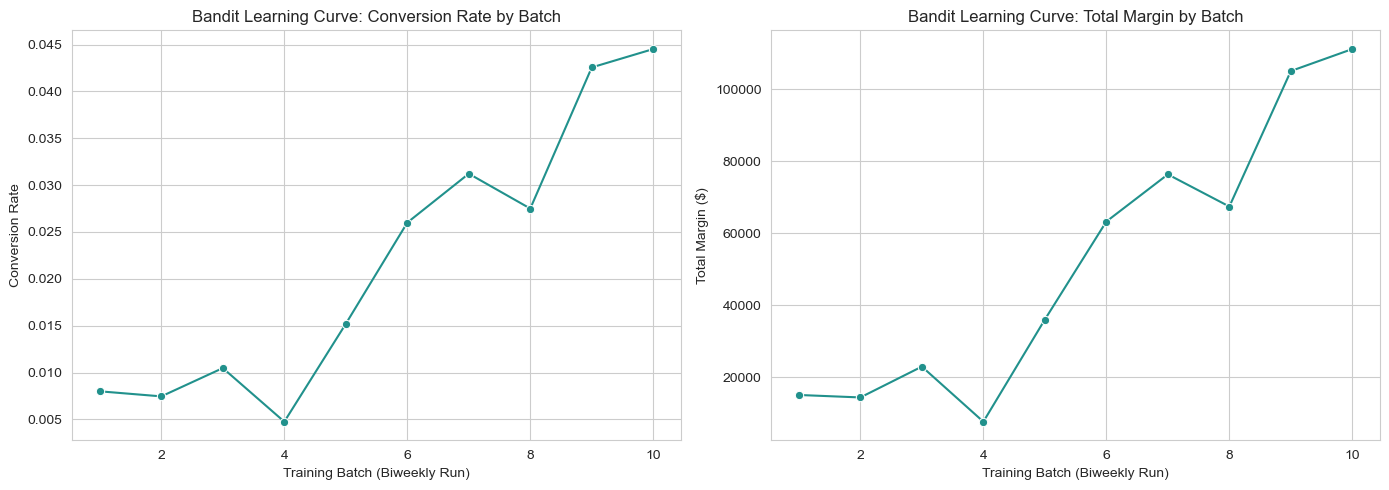

In [12]:
# ============================================================
# SECTION 3: Sequential Training Loop (Batches 1-10)
# ============================================================
# Epsilon decays from full exploration (batch 1, no model exists yet) down to
# mostly exploitation (batch 10), reflecting growing confidence in the model
# as more biweekly campaign data accumulates.

EPSILON_SCHEDULE = np.linspace(1.0, 0.05, 10)
RNG = np.random.default_rng(42)

bandit_pipeline = None   # no policy trained yet (cold start)
training_log = []        # accumulated (context, chosen action, reward) rows
batch_performance = []   # per-batch KPIs, to visualize the learning curve

for batch_idx in range(1, 11):
    leads_batch = globals()[f"train_leads_optimized_{batch_idx}"]
    epsilon = EPSILON_SCHEDULE[batch_idx - 1]

    # 1. Select an offer for each customer via the epsilon-greedy policy
    chosen_actions = epsilon_greedy_actions(leads_batch, ACTION_TABLE, bandit_pipeline, epsilon, RNG)

    # 2. Assemble the offer dataframe: original columns untouched + offer flags
    offer_batch = leads_batch.copy()
    offer_batch[OFFER_FLAG_COLS] = chosen_actions.values

    # 3. Run the simulation — the ONLY source of ground-truth reward.
    results_batch = sim(offer_batch)

    # 4. Log this batch's (context, action, reward) rows for training
    batch_rows = leads_batch[CATEGORICAL_COLS + NUMERIC_COLS].reset_index(drop=True).copy()
    batch_rows[OFFER_FLAG_COLS] = chosen_actions.values
    batch_rows["converted"] = results_batch["converted"].astype(int).values
    training_log.append(batch_rows)

    # 5. Retrain the policy on ALL data collected so far (cumulative retraining).
    cumulative_data = pd.concat(training_log, ignore_index=True)
    X_train = cumulative_data[CATEGORICAL_COLS + NUMERIC_COLS + OFFER_FLAG_COLS]
    y_train = cumulative_data["converted"]

    bandit_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)),
    ])
    bandit_pipeline.fit(X_train, y_train)

    # 6. Track batch KPIs
    batch_performance.append({
        "batch": batch_idx,
        "epsilon": epsilon,
        "conversion_rate": results_batch["converted"].mean(),
        "total_margin": results_batch["total_margin"].sum(),
        "avg_margin_per_customer": results_batch["total_margin"].mean(),
    })
    print(f"Batch {batch_idx:>2}: epsilon={epsilon:.2f} | "
          f"conversion={results_batch['converted'].mean():.2%} | "
          f"margin=${results_batch['total_margin'].sum():,.0f}")

performance_df = pd.DataFrame(batch_performance)

# Learning curve: does the policy actually improve as epsilon decays?
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.lineplot(data=performance_df, x="batch", y="conversion_rate", marker="o",
             ax=axes[0], color=sns.color_palette(PALETTE, 1)[0])
axes[0].set_title("Bandit Learning Curve: Conversion Rate by Batch")
axes[0].set_xlabel("Training Batch (Biweekly Run)")
axes[0].set_ylabel("Conversion Rate")

sns.lineplot(data=performance_df, x="batch", y="total_margin", marker="o",
             ax=axes[1], color=sns.color_palette(PALETTE, 1)[0])
axes[1].set_title("Bandit Learning Curve: Total Margin by Batch")
axes[1].set_xlabel("Training Batch (Biweekly Run)")
axes[1].set_ylabel("Total Margin ($)")
plt.tight_layout()
plt.show()

In [13]:
# ============================================================
# SECTION 4: Final Test Evaluation
# ============================================================

def bandit_function(leads_df: pd.DataFrame) -> pd.DataFrame:
    """
    Pure-exploitation policy (epsilon=0): assign each customer the valid
    offer with the highest model-predicted expected margin, using the final
    policy trained across all 10 batches. This is the function used both for
    our own internal check below and for the notebook's official final
    validation gate later on.
    """
    best_actions = select_best_actions(leads_df, ACTION_TABLE, bandit_pipeline)
    offer_df = leads_df.copy()
    offer_df[OFFER_FLAG_COLS] = best_actions.values
    return offer_df


optimized_offer_check = bandit_function(test_leads_optimized)
optimized_results_check = sim(optimized_offer_check)

random_offer_check = random_offer_fn(test_leads_optimized)
random_results_check = sim(random_offer_check)
low_cost_offer_check = fixed_offer(test_leads_optimized)
low_cost_results_check = sim(low_cost_offer_check)

comparison_check = pd.DataFrame({
    "Strategy": ["Random Offer", "Low-Cost Offer", "Contextual Bandit"],
    "Conversion Rate": [
        random_results_check["converted"].mean(),
        low_cost_results_check["converted"].mean(),
        optimized_results_check["converted"].mean(),
    ],
    "Total Margin ($)": [
        random_results_check["total_margin"].sum(),
        low_cost_results_check["total_margin"].sum(),
        optimized_results_check["total_margin"].sum(),
    ],
})
print("\n=== Internal Test Evaluation ===")
print(comparison_check.round(4))



=== Internal Test Evaluation ===
            Strategy  Conversion Rate  Total Margin ($)
0       Random Offer           0.0081          15668.76
1     Low-Cost Offer           0.0255          31901.38
2  Contextual Bandit           0.0417         104808.32


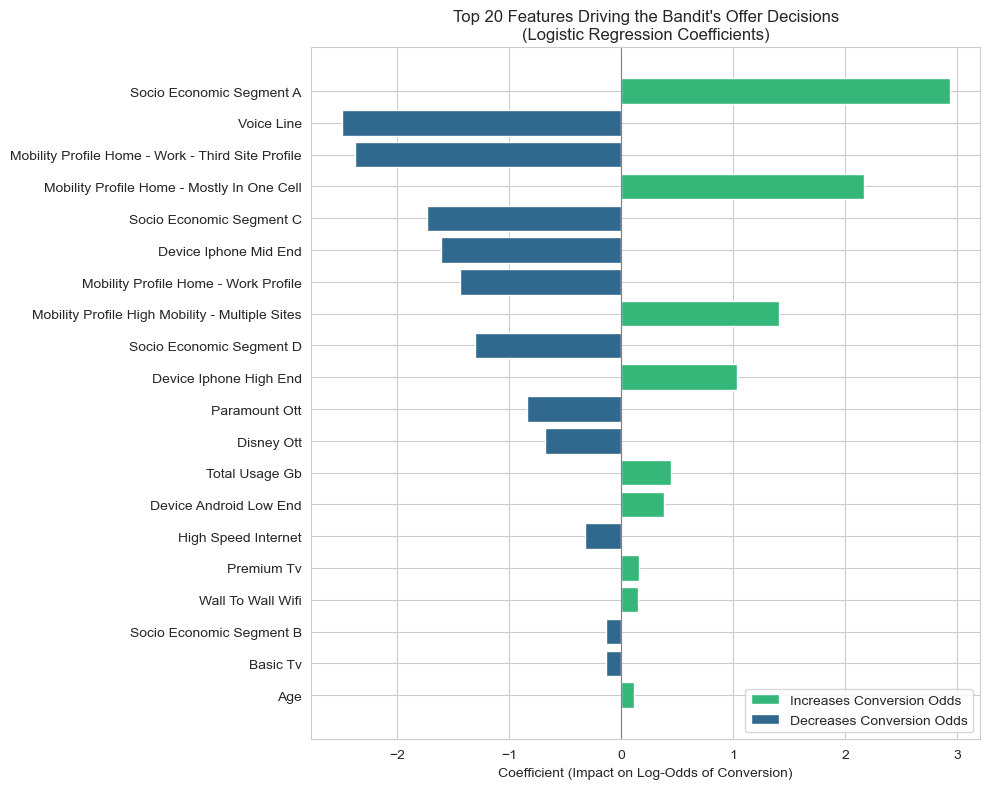

                                          feature  coefficient                 direction
                         Socio Economic Segment A     2.933762 Increases Conversion Odds
                                       Voice Line    -2.496186 Decreases Conversion Odds
Mobility Profile Home - Work - Third Site Profile    -2.378678 Decreases Conversion Odds
       Mobility Profile Home - Mostly In One Cell     2.168436 Increases Conversion Odds
                         Socio Economic Segment C    -1.731205 Decreases Conversion Odds


In [18]:
# ============================================================
# Contextual Bandit — Feature Importance Analysis
# ============================================================

from matplotlib.patches import Patch

sns.set_style("whitegrid")
PALETTE = "viridis"

# ------------------------------------------------------------
# 1. Extract feature names + coefficients from the fitted pipeline
# ------------------------------------------------------------
fitted_preprocessor = bandit_pipeline.named_steps["preprocessor"]
fitted_classifier = bandit_pipeline.named_steps["classifier"]

feature_names = fitted_preprocessor.get_feature_names_out()
coefficients = fitted_classifier.coef_[0]

assert len(feature_names) == len(coefficients), "Feature name / coefficient length mismatch"


def clean_feature_name(name: str) -> str:
    """Turn sklearn's auto-generated names (e.g. 'categorical__socio_economic_segment_A')
    into readable labels for a non-technical audience."""
    name = name.split("__", 1)[-1]     # drop the ColumnTransformer's transformer prefix
    name = name.replace("offer_", "")  # drop the offer_ prefix on action-flag features
    return name.replace("_", " ").title()


feature_importance = pd.DataFrame({
    "feature": [clean_feature_name(f) for f in feature_names],
    "coefficient": coefficients,
})
feature_importance["abs_coefficient"] = feature_importance["coefficient"].abs()
feature_importance["direction"] = np.where(
    feature_importance["coefficient"] >= 0, "Increases Conversion Odds", "Decreases Conversion Odds"
)
feature_importance = feature_importance.sort_values("abs_coefficient", ascending=False)

# ------------------------------------------------------------
# 2. Visualization: top features by absolute impact on conversion odds
# ------------------------------------------------------------

TOP_N = 20
top_features = feature_importance.head(TOP_N).sort_values("abs_coefficient")  # ascending, for a clean barh top-down read

bar_colors = top_features["direction"].map({
    "Increases Conversion Odds": sns.color_palette(PALETTE, 2)[1],
    "Decreases Conversion Odds": sns.color_palette(PALETTE, 2)[0],
})

plt.figure(figsize=(10, 8))
plt.barh(top_features["feature"], top_features["coefficient"], color=bar_colors)
plt.axvline(0, color="grey", linewidth=0.8)
plt.title(f"Top {TOP_N} Features Driving the Bandit's Offer Decisions\n(Logistic Regression Coefficients)")
plt.xlabel("Coefficient (Impact on Log-Odds of Conversion)")
plt.ylabel("")
plt.legend(
    handles=[
        Patch(facecolor=sns.color_palette(PALETTE, 2)[1], label="Increases Conversion Odds"),
        Patch(facecolor=sns.color_palette(PALETTE, 2)[0], label="Decreases Conversion Odds"),
    ],
    loc="lower right",
)
plt.tight_layout()
plt.show()

print(feature_importance.head(5)[["feature", "coefficient", "direction"]].to_string(index=False))


=== Total Expected Margin by Scenario ===
            Scenario  Total Expected Margin ($)
0       Random Offer                   15668.76
1     Low-Cost Offer                   31901.38
2  Contextual Bandit                  104808.32

=== Financial Lift: Contextual Bandit vs. Baselines ===
vs. Random Offer:   $89,139.56 (+568.9%)
vs. Low-Cost Offer: $72,906.94 (+228.5%)


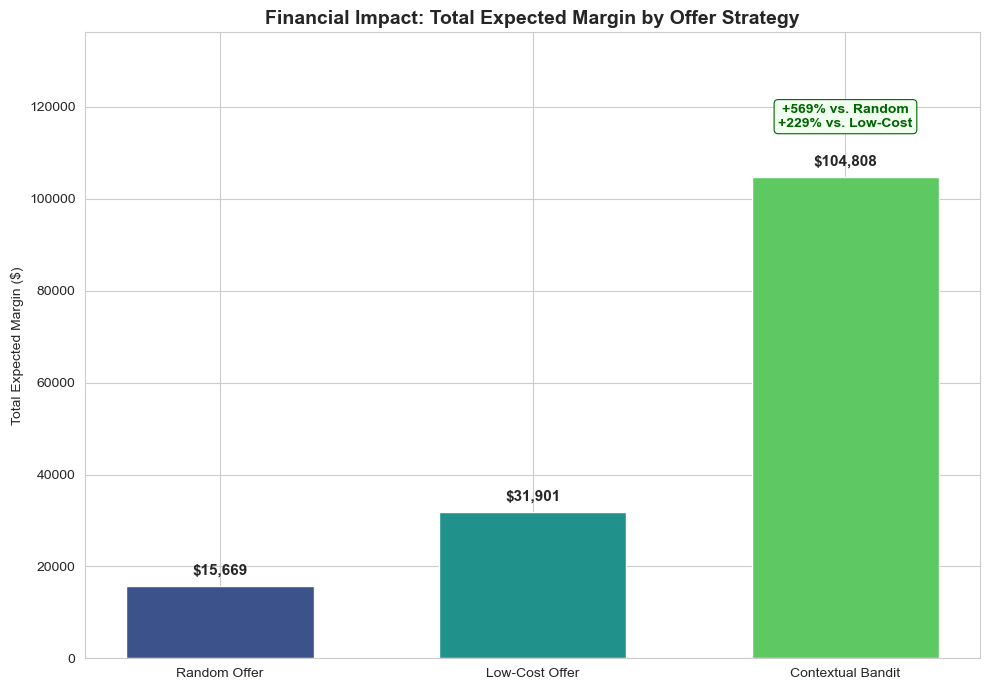


=== Executive Summary ===
Our Contextual Bandit model generated a total expected margin of $104,808.32 on the held-out test set, an absolute increase of $89,139.56 (+568.9%) over the Random offer strategy, and $72,906.94 (+228.5%) over the traditional fixed Low-Cost strategy.


In [20]:
# ============================================================
# Financial Impact Comparison: Random vs. Low-Cost vs. Contextual Bandit
# ============================================================

sns.set_style("whitegrid")
PALETTE = "viridis"

# ------------------------------------------------------------
# 1. Data Aggregation
# ------------------------------------------------------------
scenarios = {
    "Random Offer": random_results_check,
    "Low-Cost Offer": low_cost_results_check,
    "Contextual Bandit": optimized_results_check,
}

# Total expected margin: sum of total_margin among converted customers only
# (mathematically equal to summing total_margin over all rows, since
# non-converted customers carry total_margin == 0 — filtering explicitly
# keeps the calculation self-documenting)
total_margin_by_scenario = {
    name: df.loc[df["converted"], "total_margin"].sum()
    for name, df in scenarios.items()
}

margin_summary = pd.DataFrame({
    "Scenario": list(total_margin_by_scenario.keys()),
    "Total Expected Margin ($)": list(total_margin_by_scenario.values()),
})
print("=== Total Expected Margin by Scenario ===")
print(margin_summary.round(2))

# ------------------------------------------------------------
# 2. Financial Calculations: Absolute & Percentage Lift
# ------------------------------------------------------------
bandit_margin = total_margin_by_scenario["Contextual Bandit"]
random_margin = total_margin_by_scenario["Random Offer"]
low_cost_margin = total_margin_by_scenario["Low-Cost Offer"]

lift_vs_random_abs = bandit_margin - random_margin
lift_vs_random_pct = (lift_vs_random_abs / random_margin) * 100

lift_vs_low_cost_abs = bandit_margin - low_cost_margin
lift_vs_low_cost_pct = (lift_vs_low_cost_abs / low_cost_margin) * 100

print("\n=== Financial Lift: Contextual Bandit vs. Baselines ===")
print(f"vs. Random Offer:   ${lift_vs_random_abs:,.2f} ({lift_vs_random_pct:+.1f}%)")
print(f"vs. Low-Cost Offer: ${lift_vs_low_cost_abs:,.2f} ({lift_vs_low_cost_pct:+.1f}%)")

# ------------------------------------------------------------
# 3. Visualization
# ------------------------------------------------------------
colors = sns.color_palette(PALETTE, 3)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.bar(margin_summary["Scenario"], margin_summary["Total Expected Margin ($)"], color=colors, width=0.6)

# Annotate each bar with its absolute dollar value
for bar in bars:
    height = bar.get_height()
    ax.annotate(
        f"${height:,.0f}",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 6), textcoords="offset points",
        ha="center", va="bottom", fontsize=11, fontweight="bold",
    )

# Highlight the % lift explicitly above the Contextual Bandit bar
bandit_bar = bars[2]
bandit_top = bandit_bar.get_height()
ax.annotate(
    f"+{lift_vs_random_pct:.0f}% vs. Random\n+{lift_vs_low_cost_pct:.0f}% vs. Low-Cost",
    xy=(bandit_bar.get_x() + bandit_bar.get_width() / 2, bandit_top),
    xytext=(0, 34), textcoords="offset points",
    ha="center", va="bottom", fontsize=10, fontweight="bold",
    color="darkgreen",
    bbox=dict(boxstyle="round,pad=0.3", fc="honeydew", ec="darkgreen", lw=0.8),
)

ax.set_title("Financial Impact: Total Expected Margin by Offer Strategy", fontsize=14, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Total Expected Margin ($)")
ax.set_ylim(0, bandit_top * 1.3)  # headroom for the lift annotation
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Business Executive Summary
# ------------------------------------------------------------
print("\n=== Executive Summary ===")
print(
    f"Our Contextual Bandit model generated a total expected margin of "
    f"${bandit_margin:,.2f} on the held-out test set, an absolute increase of "
    f"${lift_vs_random_abs:,.2f} ({lift_vs_random_pct:+.1f}%) over the Random "
    f"offer strategy, and ${lift_vs_low_cost_abs:,.2f} ({lift_vs_low_cost_pct:+.1f}%) "
    "over the traditional fixed Low-Cost strategy."
)



=== Suggested Offer Distribution (Contextual Bandit) ===
                                                                             offer_description  pct_of_leads
                                           Low Speed Internet + Premium TV + Wall to Wall Wifi         52.80
                                          High Speed Internet + Premium TV + Wall to Wall Wifi         40.12
                             High Speed Internet + Premium TV + Disney OTT + Wall to Wall Wifi          3.92
             High Speed Internet + Premium TV + Disney OTT + Paramount OTT + Wall to Wall Wifi          2.82
High Speed Internet + Premium TV + Disney OTT + Paramount OTT + Voice Line + Wall to Wall Wifi          0.34


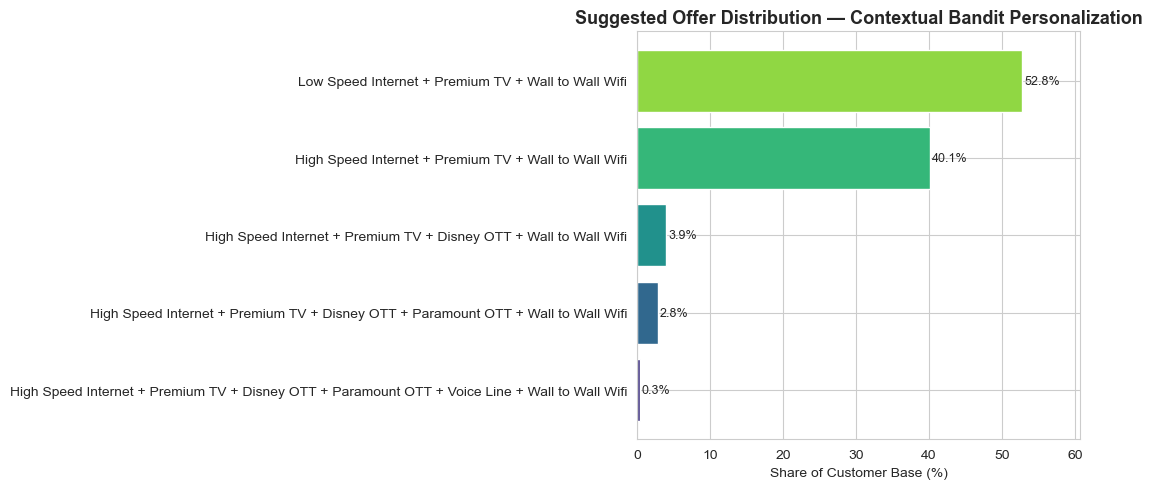


The Contextual Bandit actively used 5 distinct offer combinations out of 96 valid actions in the action space (5.2% of the space), confirming the policy personalizes offers rather than converging on a single one-size-fits-all bundle.


In [21]:
# ============================================================
# Suggested Offer Distribution — Contextual Bandit Personalization Check
# ============================================================

sns.set_style("whitegrid")
PALETTE = "viridis"

# ------------------------------------------------------------
# 1. Data Aggregation
# ------------------------------------------------------------
offer_results = optimized_results_check.loc[:, ~optimized_results_check.columns.duplicated()]

offer_distribution = (
    offer_results["offer_description"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("pct_of_leads")
    .reset_index()
    .rename(columns={"index": "offer_description"})
    .sort_values("pct_of_leads", ascending=False)
)

print("=== Suggested Offer Distribution (Contextual Bandit) ===")
print(offer_distribution.round(2).to_string(index=False))

# ------------------------------------------------------------
# 2. Visualization
# ------------------------------------------------------------
plot_data = offer_distribution.sort_values("pct_of_leads")  # ascending, for a clean top-down barh read

fig_height = max(5, 0.4 * len(plot_data))  # scale figure height to the number of distinct bundles
plt.figure(figsize=(11, fig_height))
bars = plt.barh(
    plot_data["offer_description"], plot_data["pct_of_leads"],
    color=sns.color_palette(PALETTE, len(plot_data)),
)

for bar, pct in zip(bars, plot_data["pct_of_leads"]):
    plt.text(
        bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
        f"{pct:.1f}%", va="center", ha="left", fontsize=9,
    )

plt.title("Suggested Offer Distribution — Contextual Bandit Personalization", fontsize=13, fontweight="bold")
plt.xlabel("Share of Customer Base (%)")
plt.ylabel("")
plt.xlim(0, plot_data["pct_of_leads"].max() * 1.15)  # headroom for the % labels
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Personalization Metric
# ------------------------------------------------------------
n_unique_offers_used = offer_results["offer_description"].nunique()
n_total_action_space = len(ACTION_TABLE)
print(
    f"\nThe Contextual Bandit actively used {n_unique_offers_used} distinct offer "
    f"combinations out of {n_total_action_space} valid actions in the action space "
    f"({n_unique_offers_used / n_total_action_space:.1%} of the space), "
    "confirming the policy personalizes offers rather than converging on a "
    "single one-size-fits-all bundle."
)


## Validate your final result and report final KPIs

In [14]:
#Do not modify this cell
import pandas as pd
final_test_validation_base = pd.read_parquet("data_and_supporting_code/final_test_validation_base.parquet")
display(final_test_validation_base.head())

random_offer_test = random_offer_fn(final_test_validation_base)
random_result_test = sim(random_offer_test)
low_cost_offer_test = fixed_offer(final_test_validation_base)
low_cost_result_test = sim(low_cost_offer_test)

,phone_number,age,socio_economic_segment,mobility_profile,device,total_usage_gb,youtube_gb,whatsapp_gb,netflix_gb,disney_gb,other_ott_gb,news_portals_gb,sports_portals_gb
0,68657357,38,A,Home - Work - Third Site Profile,Android high end,15.40,6.366,1.433,4.651,0.728,0.437,0.001,0.088
1,67560804,35,C,Home - Mostly in one cell,Android low end,30.15,4.601,4.710,4.762,0.020,7.238,0.000,2.197
2,66851741,22,C,High mobility - Multiple Sites,iPhone high end,9.19,1.171,0.235,2.522,0.163,1.286,0.010,0.001
3,66009720,33,D,Home - Mostly in one cell,Android low end,4.64,0.708,0.267,0.280,0.537,1.805,0.000,0.031
4,68824091,22,C,Home - Work profile,Android high end,12.01,4.653,1.047,1.087,0.296,0.464,0.000,0.000


In [15]:
#Write your code here, do not change the name of the offer test dataframe

optimized_offer_test   = bandit_function(final_test_validation_base)

=== Strategy Comparison ===


,Strategy,Customers,Converted,Conv. Rate,Total Margin,Margin / Convert,Margin / Customer
0,Random Offer (baseline),"50,000",430,0.9%,"$17,201",$40.00,$0.34
1,Low-Cost Offer (baseline),"50,000","1,164",2.3%,"$29,170",$25.06,$0.58
2,Contextual Bandit (ours),"50,000","2,699",5.4%,"$133,266",$49.38,$2.67


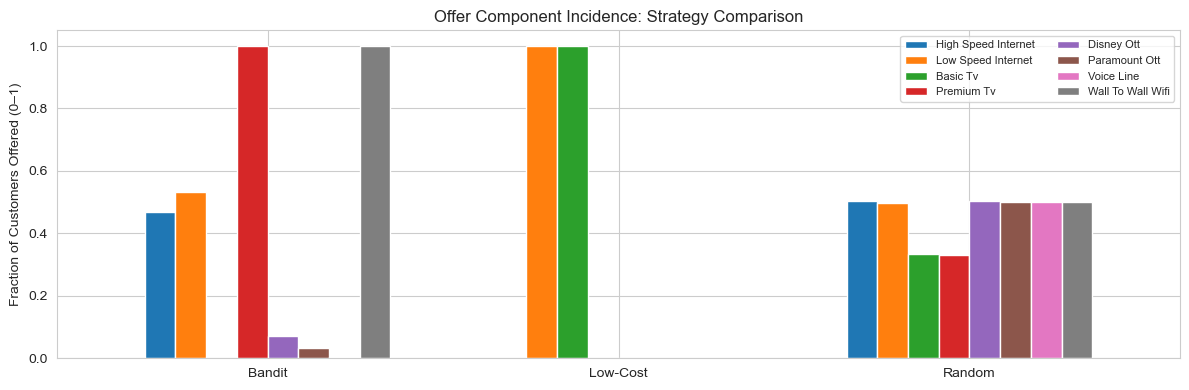

Lift vs Random Offer:   7.75× (+$116,065)
Lift vs Low-Cost Offer: 4.57× (+$104,096)


In [16]:
#Do not modify this cell
optimized_result_test = sim(optimized_offer_test)
# ── Benchmark comparison ──────────────────────────────────────────────────────
rows = []
for name, df in [
    ('Random Offer (baseline)',   random_result_test),
    ('Low-Cost Offer (baseline)', low_cost_result_test),
    ('Contextual Bandit (ours)',  optimized_result_test),
]:
    conv_df = df[df['converted']]
    rows.append({
        'Strategy':           name,
        'Customers':          f"{len(df):,}",
        'Converted':          f"{df['converted'].sum():,}",
        'Conv. Rate':         f"{df['converted'].mean():.1%}",
        'Total Margin':       f"${df['total_margin'].sum():,.0f}",
        'Margin / Convert':   f"${conv_df['total_margin'].mean():.2f}" if len(conv_df) else '—',
        'Margin / Customer':  f"${df['total_margin'].mean():.2f}",
    })
print("=== Strategy Comparison ===")
display(pd.DataFrame(rows))

# ── Offer-mix comparison ──────────────────────────────────────────────────────
offer_feature_cols = [c for c in optimized_offer_test.columns
                      if c.startswith('offer_') and c != 'offer_description']
mix = pd.DataFrame({
    'Optimized':   optimized_offer_test[offer_feature_cols].mean(),
    'Low-Cost': low_cost_offer_test[offer_feature_cols].mean(),
    'Random':   random_offer_test[offer_feature_cols].mean(),
})
fig, ax = plt.subplots(figsize=(12, 4))
mix.T.plot(kind='bar', ax=ax, width=0.7)
ax.set_title('Offer Component Incidence: Strategy Comparison')
ax.set_ylabel('Fraction of Customers Offered (0–1)')
ax.set_xticklabels(['Bandit', 'Low-Cost', 'Random'], rotation=0)
ax.legend(
    [c.replace('offer_', '').replace('_', ' ').title() for c in offer_feature_cols],
    loc='upper right', fontsize=8, ncol=2,
)
plt.tight_layout()
plt.show()

# ── Lift summary ──────────────────────────────────────────────────────────────
opt_m = optimized_result_test['total_margin'].sum()
lc_m  = low_cost_result_test['total_margin'].sum()
rnd_m = random_result_test['total_margin'].sum()
print(f"Lift vs Random Offer:   {opt_m/rnd_m:.2f}× (+${opt_m - rnd_m:,.0f})")
print(f"Lift vs Low-Cost Offer: {opt_m/lc_m:.2f}× (+${opt_m - lc_m:,.0f})")

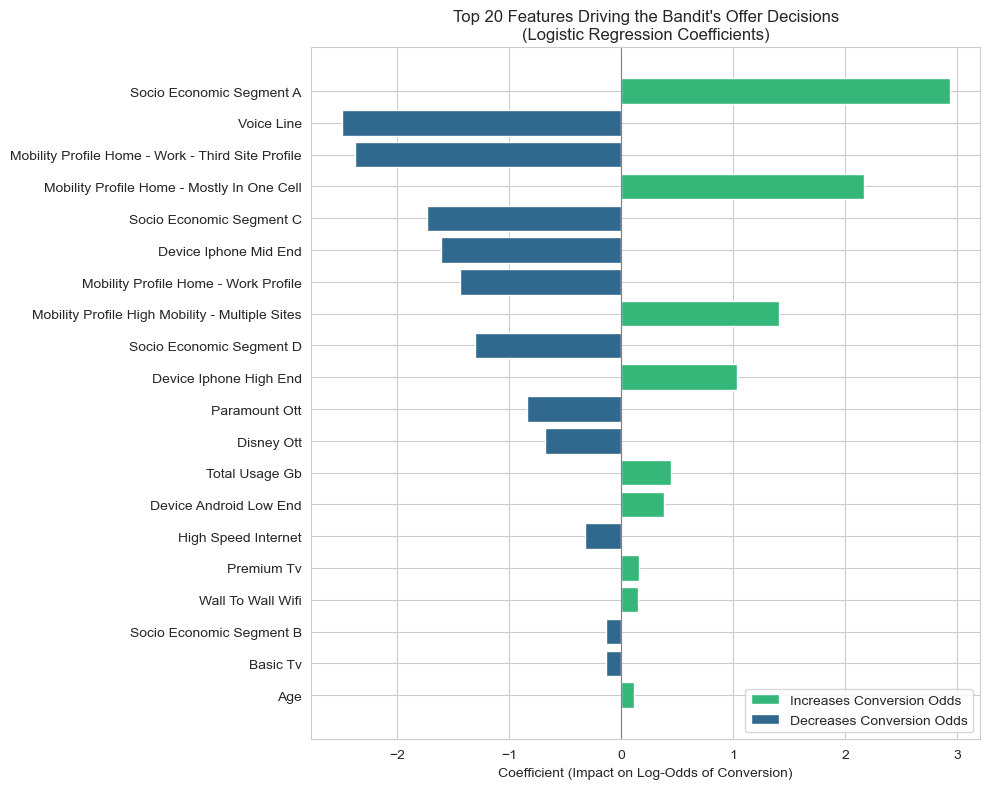


Top 5 features driving offer decisions:
                                          feature  coefficient                 direction
                         Socio Economic Segment A     2.933762 Increases Conversion Odds
                                       Voice Line    -2.496186 Decreases Conversion Odds
Mobility Profile Home - Work - Third Site Profile    -2.378678 Decreases Conversion Odds
       Mobility Profile Home - Mostly In One Cell     2.168436 Increases Conversion Odds
                         Socio Economic Segment C    -1.731205 Decreases Conversion Odds


In [22]:
# ============================================================
# PART 1: Feature Importance (Marketing Perspective)
# ============================================================

from matplotlib.patches import Patch

sns.set_style("whitegrid")
PALETTE = "viridis"

fitted_preprocessor = bandit_pipeline.named_steps["preprocessor"]
fitted_classifier = bandit_pipeline.named_steps["classifier"]

feature_names = fitted_preprocessor.get_feature_names_out()
coefficients = fitted_classifier.coef_[0]
assert len(feature_names) == len(coefficients), "Feature name / coefficient length mismatch"


def clean_feature_name(name: str) -> str:
    
    name = name.split("__", 1)[-1]
    name = name.replace("offer_", "")
    return name.replace("_", " ").title()


feature_importance = pd.DataFrame({
    "feature": [clean_feature_name(f) for f in feature_names],
    "coefficient": coefficients,
})
feature_importance["abs_coefficient"] = feature_importance["coefficient"].abs()
feature_importance["direction"] = np.where(
    feature_importance["coefficient"] >= 0, "Increases Conversion Odds", "Decreases Conversion Odds"
)
feature_importance = feature_importance.sort_values("abs_coefficient", ascending=False)

TOP_N = 20
top_features = feature_importance.head(TOP_N).sort_values("abs_coefficient")
bar_colors = top_features["direction"].map({
    "Increases Conversion Odds": sns.color_palette(PALETTE, 2)[1],
    "Decreases Conversion Odds": sns.color_palette(PALETTE, 2)[0],
})

plt.figure(figsize=(10, 8))
plt.barh(top_features["feature"], top_features["coefficient"], color=bar_colors)
plt.axvline(0, color="grey", linewidth=0.8)
plt.title(f"Top {TOP_N} Features Driving the Bandit's Offer Decisions\n(Logistic Regression Coefficients)")
plt.xlabel("Coefficient (Impact on Log-Odds of Conversion)")
plt.ylabel("")
plt.legend(
    handles=[
        Patch(facecolor=sns.color_palette(PALETTE, 2)[1], label="Increases Conversion Odds"),
        Patch(facecolor=sns.color_palette(PALETTE, 2)[0], label="Decreases Conversion Odds"),
    ],
    loc="lower right",
)
plt.tight_layout()
plt.show()

print("\nTop 5 features driving offer decisions:")
print(feature_importance.head(5)[["feature", "coefficient", "direction"]].to_string(index=False))


=== Total Expected Margin by Scenario (final_test_validation_base) ===
            Scenario  Total Expected Margin ($)
0       Random Offer                   17201.07
1     Low-Cost Offer                   29169.84
2  Contextual Bandit                  133265.72

=== Financial Lift: Contextual Bandit vs. Baselines ===
vs. Random Offer:   $116,064.65 (+674.8%)
vs. Low-Cost Offer: $104,095.88 (+356.9%)


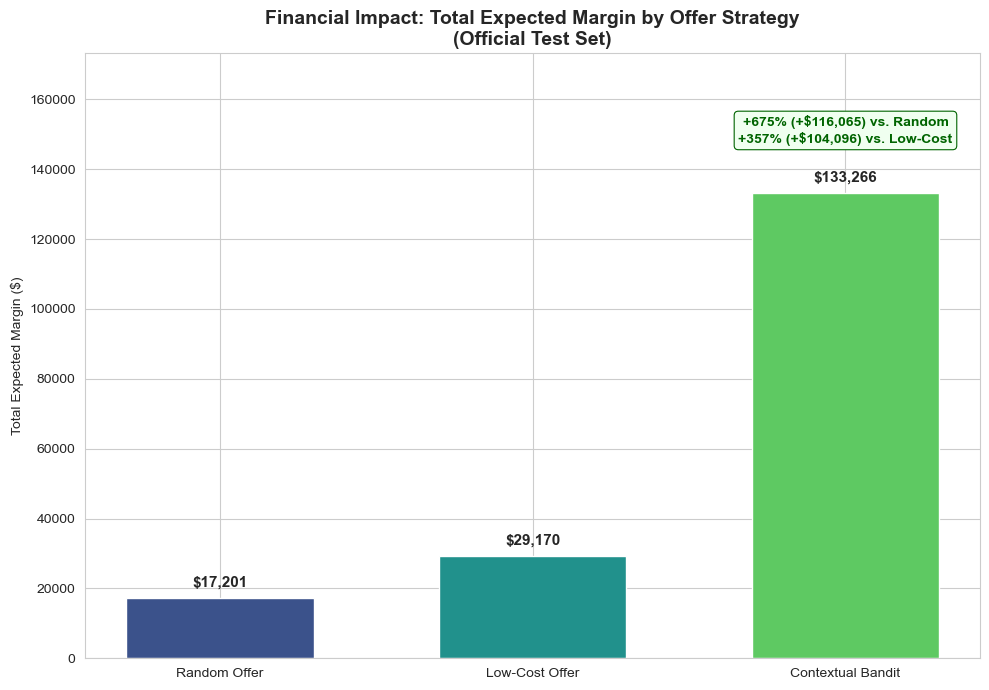

In [23]:
# ============================================================
# PART 2: Financial Impact Comparison (Executive Perspective)
# ============================================================
scenarios = {
    "Random Offer": random_result_test,
    "Low-Cost Offer": low_cost_result_test,
    "Contextual Bandit": optimized_result_test,
}

# Total expected margin: sum of total_margin among converted customers only
# (equal to summing over all rows, since non-converted rows carry margin 0 —
# filtering explicitly keeps the calculation self-documenting)
total_margin_by_scenario = {
    name: df.loc[df["converted"], "total_margin"].sum()
    for name, df in scenarios.items()
}
margin_summary = pd.DataFrame({
    "Scenario": list(total_margin_by_scenario.keys()),
    "Total Expected Margin ($)": list(total_margin_by_scenario.values()),
})
print("\n=== Total Expected Margin by Scenario (final_test_validation_base) ===")
print(margin_summary.round(2))

bandit_margin = total_margin_by_scenario["Contextual Bandit"]
random_margin = total_margin_by_scenario["Random Offer"]
low_cost_margin = total_margin_by_scenario["Low-Cost Offer"]

lift_vs_random_abs = bandit_margin - random_margin
lift_vs_random_pct = (lift_vs_random_abs / random_margin) * 100
lift_vs_low_cost_abs = bandit_margin - low_cost_margin
lift_vs_low_cost_pct = (lift_vs_low_cost_abs / low_cost_margin) * 100

print("\n=== Financial Lift: Contextual Bandit vs. Baselines ===")
print(f"vs. Random Offer:   ${lift_vs_random_abs:,.2f} ({lift_vs_random_pct:+.1f}%)")
print(f"vs. Low-Cost Offer: ${lift_vs_low_cost_abs:,.2f} ({lift_vs_low_cost_pct:+.1f}%)")

colors = sns.color_palette(PALETTE, 3)
fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.bar(margin_summary["Scenario"], margin_summary["Total Expected Margin ($)"], color=colors, width=0.6)

for bar in bars:
    height = bar.get_height()
    ax.annotate(
        f"${height:,.0f}",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 6), textcoords="offset points",
        ha="center", va="bottom", fontsize=11, fontweight="bold",
    )

bandit_bar = bars[2]
bandit_top = bandit_bar.get_height()
ax.annotate(
    f"+{lift_vs_random_pct:.0f}% (+${lift_vs_random_abs:,.0f}) vs. Random\n"
    f"+{lift_vs_low_cost_pct:.0f}% (+${lift_vs_low_cost_abs:,.0f}) vs. Low-Cost",
    xy=(bandit_bar.get_x() + bandit_bar.get_width() / 2, bandit_top),
    xytext=(0, 34), textcoords="offset points",
    ha="center", va="bottom", fontsize=10, fontweight="bold", color="darkgreen",
    bbox=dict(boxstyle="round,pad=0.3", fc="honeydew", ec="darkgreen", lw=0.8),
)

ax.set_title("Financial Impact: Total Expected Margin by Offer Strategy\n(Official Test Set)", fontsize=14, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Total Expected Margin ($)")
ax.set_ylim(0, bandit_top * 1.3)
plt.tight_layout()
plt.show()


=== Suggested Offer Distribution (Contextual Bandit, Official Test Set) ===
                                                                             offer_description  pct_of_leads
                                           Low Speed Internet + Premium TV + Wall to Wall Wifi         53.13
                                          High Speed Internet + Premium TV + Wall to Wall Wifi         39.79
                             High Speed Internet + Premium TV + Disney OTT + Wall to Wall Wifi          3.93
             High Speed Internet + Premium TV + Disney OTT + Paramount OTT + Wall to Wall Wifi          2.77
High Speed Internet + Premium TV + Disney OTT + Paramount OTT + Voice Line + Wall to Wall Wifi          0.39


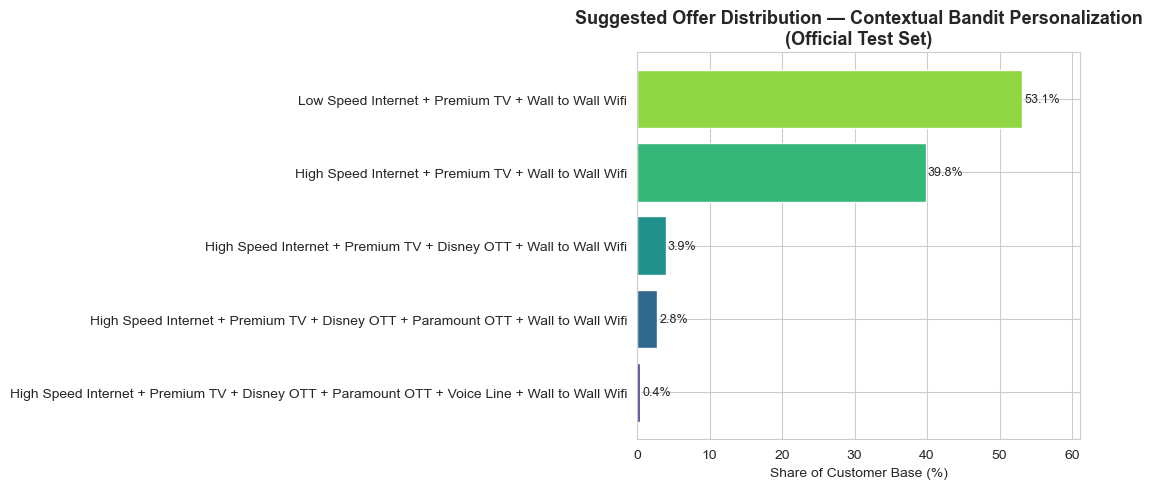


=== Executive Summary ===
Financial Lift: the Contextual Bandit generated $133,265.72 in total expected margin on the official test set — a gain of $116,064.65 (+674.8%) over Random and $104,095.88 (+356.9%) over the fixed Low-Cost strategy.
Personalization: the policy actively used 5 distinct offer combinations out of 96 valid actions (5.2% of the space), confirming it tailors offers to customer context rather than defaulting to one bundle.


In [24]:

# ============================================================
# PART 3: Suggested Offer Distribution (Personalization Proof)
# ============================================================

offer_results = optimized_result_test.loc[:, ~optimized_result_test.columns.duplicated()]

offer_distribution = (
    offer_results["offer_description"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("pct_of_leads")
    .reset_index()
    .rename(columns={"index": "offer_description"})
    .sort_values("pct_of_leads", ascending=False)
)
print("\n=== Suggested Offer Distribution (Contextual Bandit, Official Test Set) ===")
print(offer_distribution.round(2).to_string(index=False))

plot_data = offer_distribution.sort_values("pct_of_leads")
fig_height = max(5, 0.4 * len(plot_data))
plt.figure(figsize=(11, fig_height))
bars = plt.barh(
    plot_data["offer_description"], plot_data["pct_of_leads"],
    color=sns.color_palette(PALETTE, len(plot_data)),
)
for bar, pct in zip(bars, plot_data["pct_of_leads"]):
    plt.text(
        bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
        f"{pct:.1f}%", va="center", ha="left", fontsize=9,
    )
plt.title("Suggested Offer Distribution — Contextual Bandit Personalization\n(Official Test Set)", fontsize=13, fontweight="bold")
plt.xlabel("Share of Customer Base (%)")
plt.ylabel("")
plt.xlim(0, plot_data["pct_of_leads"].max() * 1.15)
plt.tight_layout()
plt.show()

n_unique_offers_used = offer_results["offer_description"].nunique()
n_total_action_space = len(ACTION_TABLE)

# ============================================================
# Consolidated Summary
# ============================================================
print("\n=== Executive Summary ===")
print(
    f"Financial Lift: the Contextual Bandit generated ${bandit_margin:,.2f} in total "
    f"expected margin on the official test set — a gain of ${lift_vs_random_abs:,.2f} "
    f"({lift_vs_random_pct:+.1f}%) over Random and ${lift_vs_low_cost_abs:,.2f} "
    f"({lift_vs_low_cost_pct:+.1f}%) over the fixed Low-Cost strategy."
)
print(
    f"Personalization: the policy actively used {n_unique_offers_used} distinct offer "
    f"combinations out of {n_total_action_space} valid actions "
    f"({n_unique_offers_used / n_total_action_space:.1%} of the space), confirming it "
    "tailors offers to customer context rather than defaulting to one bundle."
)
